In [ ]:
# @title
# ============================================================
# Download Dataset dari Google Drive
# ============================================================
!gdown "https://drive.google.com/uc?id=1o3HngJ003MgcYGuu2QC80n20zz7Dd9VB&export=download" -O PhiUSIIL_Phishing_URL_Dataset.csv

import pandas as pd

def list_features(df: pd.DataFrame, filename: str = "dataset") -> None:
    """Menampilkan informasi lengkap tentang setiap feature (kolom)."""

    total_rows, total_cols = df.shape

    print("=" * 60)
    print(f"  INFORMASI DATASET: {filename}")
    print("=" * 60)
    print(f"  Jumlah baris   : {total_rows}")
    print(f"  Jumlah kolom   : {total_cols}")
    print("=" * 60)

    print(f"\n{'No':<5} {'Nama Feature':<30} {'Tipe Data':<15} {'Missing':<10} {'Unik'}")
    print("-" * 75)

    for i, col in enumerate(df.columns, start=1):
        dtype    = str(df[col].dtype)
        missing  = df[col].isnull().sum()
        unique   = df[col].nunique()
        print(f"{i:<5} {col:<30} {dtype:<15} {missing:<10} {unique}")

    print("\n" + "=" * 60)
    print("  DAFTAR NAMA FEATURE (LIST)")
    print("=" * 60)
    features = list(df.columns)
    print(features)

    print("\n" + "=" * 60)
    print("  PREVIEW DATA (5 BARIS PERTAMA)")
    print("=" * 60)
    print(df.head().to_string(index=False))

filename = 'PhiUSIIL_Phishing_URL_Dataset.csv'
df = pd.read_csv(filename)
list_features(df, filename)

Downloading...
From: https://drive.google.com/uc?id=1o3HngJ003MgcYGuu2QC80n20zz7Dd9VB&export=download
To: /content/PhiUSIIL_Phishing_URL_Dataset.csv
100% 26.3M/26.3M [00:00<00:00, 165MB/s]
  INFORMASI DATASET: PhiUSIIL_Phishing_URL_Dataset.csv
  Jumlah baris   : 235795
  Jumlah kolom   : 10

No    Nama Feature                   Tipe Data       Missing    Unik
---------------------------------------------------------------------------
1     FILENAME                       object          0          235795
2     URL                            object          0          235370
3     URLLength                      int64           0          482
4     Domain                         object          0          220086
5     DomainLength                   int64           0          101
6     TLD                            object          0          695
7     URLSimilarityIndex             float64         0          36360
8     LargestLineLength              int64           0          26181
9    

## Exploratory Data Analysis (EDA)

### 1. Target Variable Distribution
Let's examine the distribution of the 'label' column to see the balance between legitimate (0) and phishing (1) URLs.

/tmp/ipykernel_8013/842115094.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


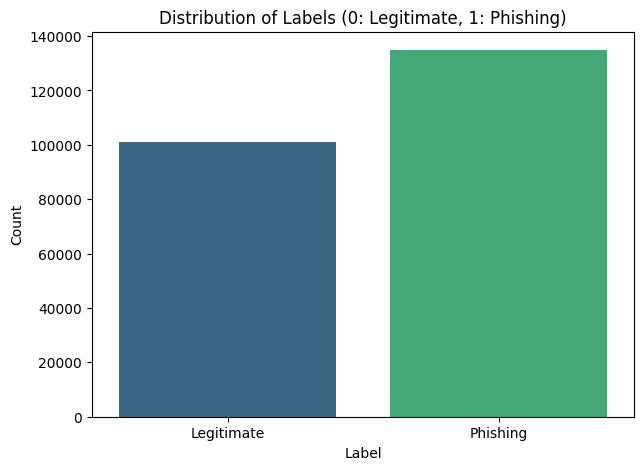

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribution of Labels (0: Legitimate, 1: Phishing)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks([0, 1], ['Legitimate', 'Phishing'])
plt.show()

### 2. URL Length Distribution
Next, let's compare the distribution of `URLLength` for both types of URLs. Phishing URLs often tend to be longer due to various obfuscation techniques.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


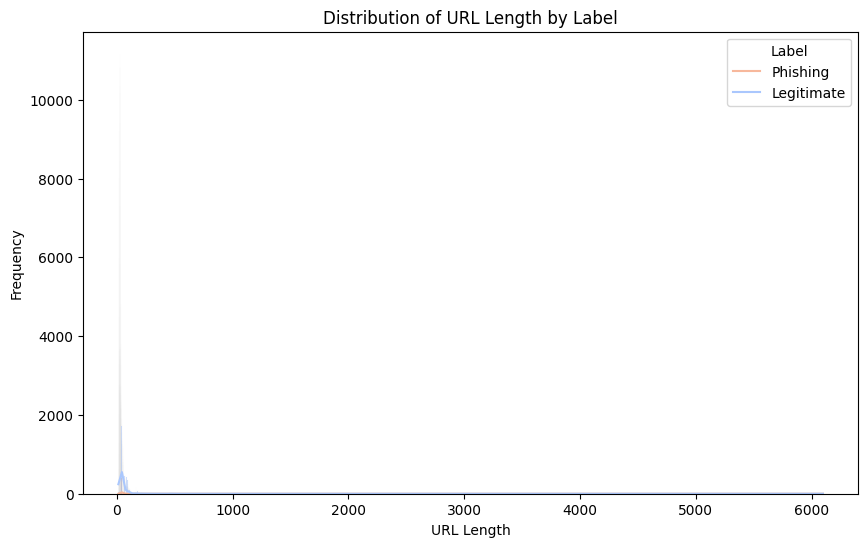

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='URLLength', hue='label', kde=True, palette='coolwarm')
plt.title('Distribution of URL Length by Label')
plt.xlabel('URL Length')
plt.ylabel('Frequency')
plt.legend(title='Label', labels=['Phishing', 'Legitimate'])
plt.show()

### 3. Domain Length Distribution
Let's also look at the `DomainLength` distribution. Similar to `URLLength`, unusual domain lengths might indicate suspicious activity.

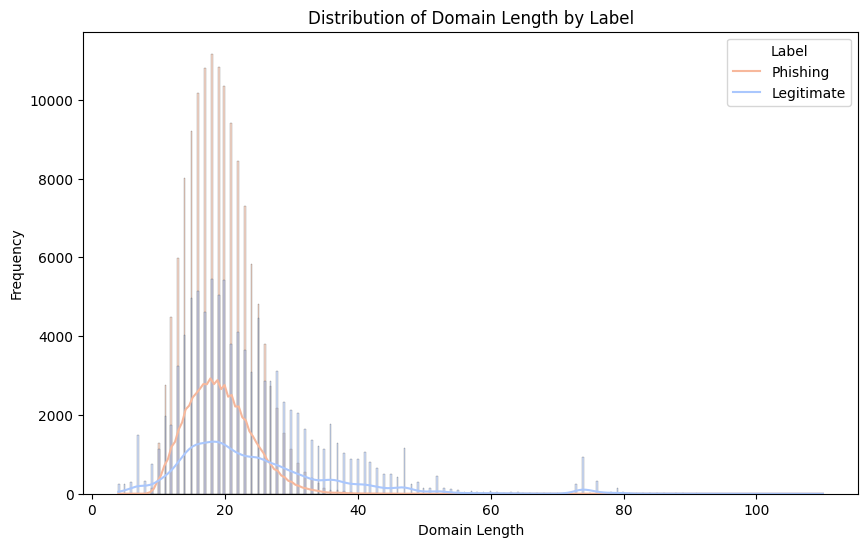

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='DomainLength', hue='label', kde=True, palette='coolwarm')
plt.title('Distribution of Domain Length by Label')
plt.xlabel('Domain Length')
plt.ylabel('Frequency')
plt.legend(title='Label', labels=['Phishing', 'Legitimate'])
plt.show()

### 4. Largest Line Length Distribution
Finally, let's analyze the `LargestLineLength` which could be an indicator of content complexity or potentially obfuscated code within the URL content.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


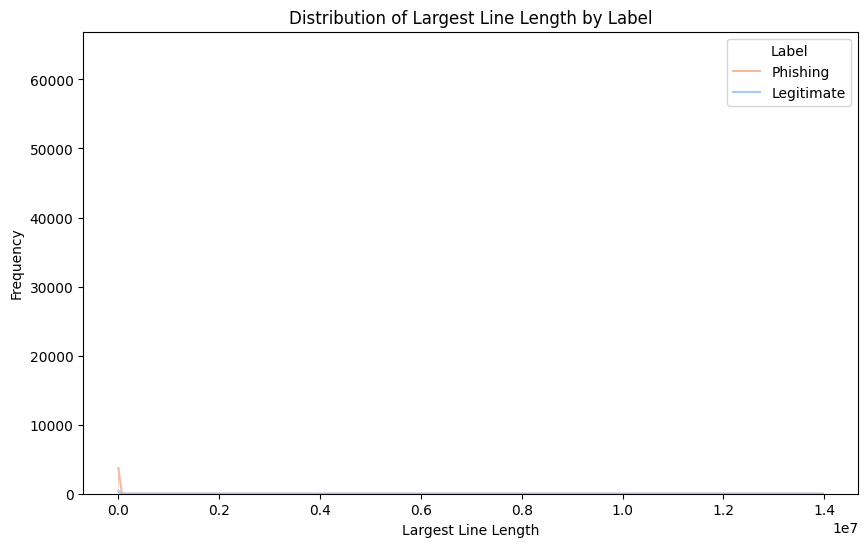

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='LargestLineLength', hue='label', kde=True, palette='coolwarm')
plt.title('Distribution of Largest Line Length by Label')
plt.xlabel('Largest Line Length')
plt.ylabel('Frequency')
plt.legend(title='Label', labels=['Phishing', 'Legitimate'])
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Train model w hyperparameter tuning**

In [ ]:
# @title
import pandas as pd
import numpy as np
import time
import re
from scipy.sparse import hstack

# Scikit-learn Modules
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

# --- TAMBAHAN IMPORT METRIK ---
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ---------------------------------------------------------
# 1. LOAD DATA
# ---------------------------------------------------------
filename = 'PhiUSIIL_Phishing_URL_Dataset.csv'

try:
    df = pd.read_csv(filename)
    df = df.drop_duplicates()
    print(f"Data dimuat. Total baris unik: {df.shape[0]}")
except Exception as e:
    print(f"Error: {e}")
    exit()

# ---------------------------------------------------------
# 2. FEATURE ENGINEERING (STATISTIK + TEKS)
# ---------------------------------------------------------
numeric_features = ['URLLength', 'DomainLength', 'LargestLineLength']
available_numeric = [f for f in numeric_features if f in df.columns]
X_numeric = df[available_numeric]

scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric)

print("Sedang memproses TF-IDF pada URL...")
def tokenizer_url(url):
    tokens = re.split(r'[./\-_?&=]', str(url))
    return " ".join([t for t in tokens if t])

df['URL_clean'] = df['URL'].apply(tokenizer_url)

tfidf = TfidfVectorizer(max_features=5000, lowercase=True)
X_text = tfidf.fit_transform(df['URL_clean'])

# C. Gabung Fitur (Dan mengambil 1 fitur target, yaitu 'label')
X_final = hstack([X_numeric_scaled, X_text])
y = df['label']
print(f"Total Fitur setelah digabung: {X_final.shape[1]}")

# =========================================================
# --- KODE TAMBAHAN: RINGKASAN PENGGUNAAN FITUR DATASET ---
# =========================================================
print("\n--- RINGKASAN PENGGUNAAN FITUR DARI DATASET ---")
semua_kolom = [col for col in df.columns if col != 'URL_clean']
fitur_numerik_dipakai = available_numeric
fitur_teks_dipakai = ['URL']
fitur_target = ['label']
semua_fitur_dipakai = fitur_numerik_dipakai + fitur_teks_dipakai + fitur_target
fitur_tidak_dipakai = [col for col in semua_kolom if col not in semua_fitur_dipakai]

print(f"Total Kolom Asli Dataset: {len(semua_kolom)} -> {semua_kolom}")
print(f"\n✅ FITUR YANG DIPAKAI (Total: {len(semua_fitur_dipakai)}):")
print(f"   - Numerik : {fitur_numerik_dipakai}")
print(f"   - Teks    : {fitur_teks_dipakai} (Dikonversi menjadi {X_text.shape[1]} dimensi dengan TF-IDF)")
print(f"   - Target  : {fitur_target}")
print(f"\n❌ FITUR YANG DIBUANG/TIDAK DIPAKAI (Total: {len(fitur_tidak_dipakai)}):")
print(f"   - {fitur_tidak_dipakai}")
print("=" * 55 + "\n")

# ---------------------------------------------------------
# 3. SPLIT DATA
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)

# ---------------------------------------------------------
# 4. HYPERPARAMETER TUNING UNTUK BANYAK MODEL
# ---------------------------------------------------------
print("\n--- MULAI HYPERPARAMETER TUNING MASSAL ---")
print("Mohon tunggu, komputer sedang mencari settingan terbaik untuk tiap model...")

model_dasar = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

param_grids = {
    "Decision Tree": {
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 10]
    },
    "Random Forest": {
        'n_estimators': [50, 100],
        'max_depth': [None, 20]
    },
    "XGBoost": {
        'n_estimators': [50, 100],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5]
    }
}

tuned_models = {}

for nama_model in model_dasar.keys():
    print(f"\n⚙️ Sedang Tuning: {nama_model} ...")
    grid_search = GridSearchCV(
        estimator=model_dasar[nama_model],
        param_grid=param_grids[nama_model],
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    tuned_models[nama_model] = grid_search.best_estimator_
    print(f"  ✅ Selesai! Settingan Terbaik: {grid_search.best_params_}")
    print(f"  📊 Akurasi (Validasi): {grid_search.best_score_ * 100:.4f}%") # Format 4 desimal

# ---------------------------------------------------------
# 5. EVALUASI AKHIR (Akurasi, Recall, Precision, F1)
# ---------------------------------------------------------
results = []
print("\n" + "="*55)
print("--- EVALUASI AKHIR SEMUA MODEL PADA DATA UJIAN ---")
print("="*55)

for name, model in tuned_models.items():
    print(f"\n[Evaluasi] {name}:")

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Menghitung Metrik Dasar (Macro Average untuk menyeimbangkan kelas 0 dan 1)
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)

    rec_train = recall_score(y_train, y_pred_train, average='macro')
    rec_test = recall_score(y_test, y_pred_test, average='macro')

    prec_train = precision_score(y_train, y_pred_train, average='macro')
    prec_test = precision_score(y_test, y_pred_test, average='macro')

    f1_train = f1_score(y_train, y_pred_train, average='macro')
    f1_test = f1_score(y_test, y_pred_test, average='macro')

    # Menampilkan Laporan Klasifikasi Rinci (Mencegah pembulatan ke 1.00)
    print(f"Laporan Klasifikasi untuk {name}:")
    print(classification_report(y_test, y_pred_test, digits=4))

# Menyimpan hasil untuk ditabelkan
    results.append({
        'Model': name,
        'Test Acc': acc_test,
        'Test Precision': prec_test,
        'Test Recall': rec_test,
        'Test F1-Score': f1_test,
        'Train Acc': acc_train,
        'Train Precision': prec_train, # Tambahan
        'Train Recall': rec_train,     # <-- INI YANG SEMPAT HILANG
        'Train F1-Score': f1_train
    })

# Tampilkan Hasil dalam Tabel
df_results = pd.DataFrame(results)
# Setting pandas untuk menampilkan 4 angka di belakang koma secara konsisten
pd.options.display.float_format = '{:,.4f}'.format

print("\n--- TABEL PERBANDINGAN FINAL METRIK ---")
print(df_results.to_string(index=False)) # to_string(index=False) agar tabel lebih rapi

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi Test Metrics untuk memudahkan perbandingan di Paper
df_melt = df_results.melt(
    id_vars="Model",
    value_vars=["Test Acc", "Test Precision", "Test Recall", "Test F1-Score"],
    var_name="Metrik",
    value_name="Skor"
)

plt.figure(figsize=(12, 6))
sns.barplot(x='Skor', y='Model', hue='Metrik', data=df_melt, palette='Set2')
# Kita set batas bawahnya di 0.990 supaya perbedaan super tipis (0.998 vs 0.999) bisa terlihat di grafik
plt.xlim(0.9900, 1.0000)
plt.title('Perbandingan Detail Performa Model pada Data Ujian')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Data dimuat. Total baris unik: 235795
Sedang memproses TF-IDF pada URL...
Total Fitur setelah digabung: 5003

--- RINGKASAN PENGGUNAAN FITUR DARI DATASET ---
Total Kolom Asli Dataset: 10 -> ['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'TLD', 'URLSimilarityIndex', 'LargestLineLength', 'Title', 'label']

✅ FITUR YANG DIPAKAI (Total: 5):
   - Numerik : ['URLLength', 'DomainLength', 'LargestLineLength']
   - Teks    : ['URL'] (Dikonversi menjadi 5000 dimensi dengan TF-IDF)
   - Target  : ['label']

❌ FITUR YANG DIBUANG/TIDAK DIPAKAI (Total: 5):
   - ['FILENAME', 'Domain', 'TLD', 'URLSimilarityIndex', 'Title']


--- MULAI HYPERPARAMETER TUNING MASSAL ---
Mohon tunggu, komputer sedang mencari settingan terbaik untuk tiap model...

⚙️ Sedang Tuning: Decision Tree ...


KeyboardInterrupt: 

Confusion Matrix tabel

In [ ]:
# @title
# Import library tambahan yang dibutuhkan
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display

print("--- MENGHITUNG CONFUSION MATRIX ---")

# Siapkan list untuk menyimpan data tabel
cm_data = []

# Siapkan canvas / figure untuk visualisasi berdampingan
# Jumlah kolom disesuaikan dengan jumlah model yang ada di 'tuned_models'
num_models = len(tuned_models)
fig, axes = plt.subplots(1, num_models, figsize=(5 * num_models, 5))

# Jika hanya 1 model, axes tidak berbentuk array, jadi kita bungkus ke dalam list
if num_models == 1:
    axes = [axes]

# Loop untuk tiap model
for i, (name, model) in enumerate(tuned_models.items()):
    # 1. Lakukan Prediksi
    y_pred_test = model.predict(X_test)

    # 2. Buat Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_test)

    # 3. Ekstrak nilai untuk Tabel (Asumsi label binary: 0 dan 1)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        cm_data.append({
            'Model': name,
            'True Negative (TN)': tn,
            'False Positive (FP)': fp,
            'False Negative (FN)': fn,
            'True Positive (TP)': tp
        })
    else:
        # Jika bukan binary (multiclass)
        cm_data.append({
            'Model': name,
            'Catatan': 'Format multiclass, lihat visualisasi.'
        })

    # 4. Plotting Heatmap di subplot yang sesuai
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False, annot_kws={"size": 14})
    axes[i].set_title(f'{name}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Predicted Label', fontsize=12)
    axes[i].set_ylabel('True Label', fontsize=12)

# Tampilkan Visualisasi
plt.tight_layout()
plt.show()

# Tampilkan Tabel
print("\n--- TABEL RINCIAN CONFUSION MATRIX ---")
df_cm = pd.DataFrame(cm_data)
display(df_cm) # 'display' membuat tabel terlihat rapi di Google Colab

**Correlation Matrix**

---



Data dimuat ulang dari PhiUSIIL_Phishing_URL_Dataset.csv


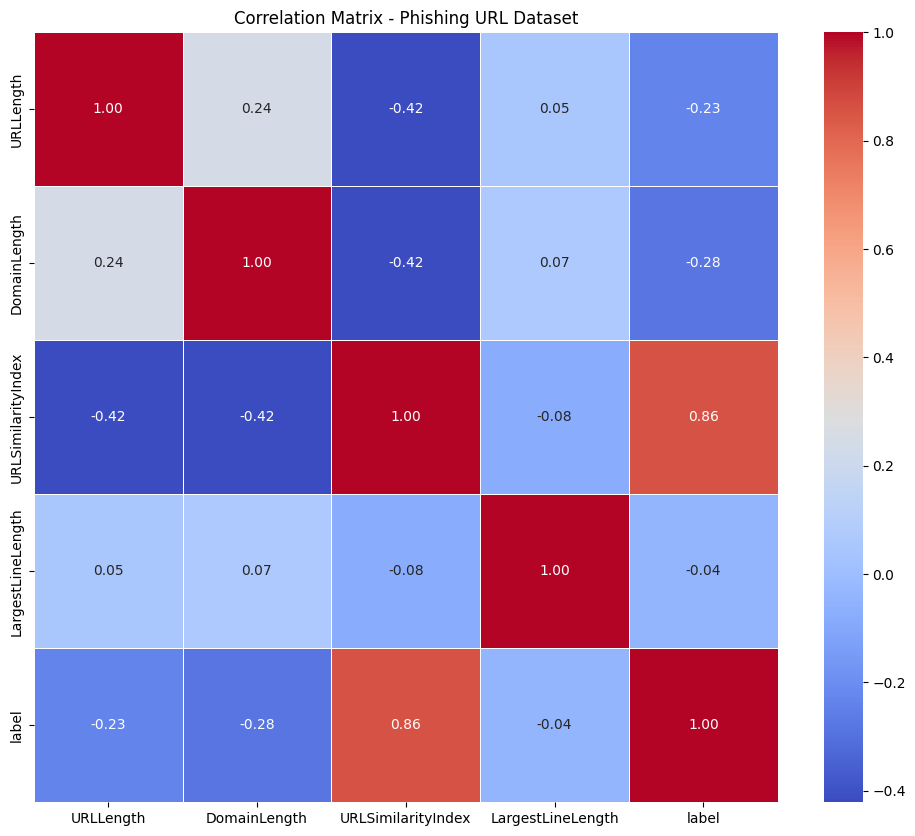

In [ ]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Memastikan variabel 'df' sudah didefinisikan
try:
    df
except NameError:
    # Load dataset jika variabel df belum ada di memori
    filename = 'PhiUSIIL_Phishing_URL_Dataset.csv'
    df = pd.read_csv(filename)
    print(f"Data dimuat ulang dari {filename}")

# Memilih kolom numerik saja untuk korelasi
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Menghitung matriks korelasi
corr_matrix = numeric_df.corr()

# Visualisasi dengan Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix - Phishing URL Dataset')
plt.show()

Export

In [ ]:
# @title
import joblib

# ... (Pastikan kode Anda yang di atas sudah berjalan semua sampai visualisasi) ...

print("\n--- PROSES PENYIMPANAN MODEL DAN PREPROCESSOR ---")

# 1. Simpan Preprocessor (SANGAT PENTING untuk prediksi data baru nanti)
joblib.dump(scaler, 'scaler_phishing.joblib')
joblib.dump(tfidf, 'tfidf_phishing.joblib')
print("✅ Berhasil menyimpan Scaler dan TF-IDF Vectorizer!")

# 2. Simpan Model
# Di kode Anda, model tersimpan di dalam dictionary 'models'.
# Mari kita ambil dan simpan model XGBoost dan Random Forest-nya.

xgb_model = tuned_models["XGBoost"]
joblib.dump(xgb_model, 'XGBoost_Phishing.joblib')
print("✅ Berhasil menyimpan model XGBoost!")

rf_model = tuned_models["Random Forest"]
joblib.dump(rf_model, 'RandomForest_Phishing.joblib')
print("✅ Berhasil menyimpan model Random Forest!")

dt_model = tuned_models["Decision Tree"]
joblib.dump(dt_model, 'DecisionTree_Phishing.joblib')
print("✅ Berhasil menyimpan model Decision Tree!")

# 3. Download File ke Komputer (Khusus jika Anda menggunakan Google Colab)
from google.colab import files

print("\nMemulai proses unduhan ke komputer Anda...")
files.download('scaler_phishing.joblib')
files.download('tfidf_phishing.joblib')
files.download('XGBoost_Phishing.joblib')
files.download('RandomForest_Phishing.joblib') # Hilangkan tanda '#' jika ingin mendownload RF juga
files.download('DecisionTree_Phishing.joblib')

## Analyze URLs with Local Qwen Model
Make sure your laptop is running the local server (`./run_qwen.sh`) and paste the ngrok URL below.

In [ ]:
!pip install -q openai

from openai import OpenAI

# ⚠️ REPLACE THIS WITH THE NGROK URL FROM YOUR LAPTOP TERMINAL
LAPTOP_API_URL = "https://rope-saloon-groggy.ngrok-free.dev/v1"

client = OpenAI(
    base_url=LAPTOP_API_URL,
    api_key="empty"
)

# Let's take the first URL from your dataset to test
sample_url = df.iloc[0]['URL']

print(f"Sending URL to local Qwen model: {sample_url}\n")

response = client.chat.completions.create(
    model="Qwen/Qwen2.5-3B-Instruct",
    messages=[
        {"role": "system", "content": "You are a cybersecurity expert. Analyze the given URL for signs of phishing. Keep it brief."},
        {"role": "user", "content": f"Analyze this URL: {sample_url}"}
    ]
)

print("Qwen Analysis:")
print(response.choices[0].message.content)
